## Data Analysis Python Project - Blinkit Analyze

#### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Import Raw Data**

In [2]:
df = pd.read_csv("blinkit_data.csv")

In [3]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [4]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


#### Size of Data

In [5]:
print("Size of Data:",df.shape)

Size of Data: (8523, 12)


#### Field Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [8]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### Data Cleaning

In [9]:
# check null value
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [10]:
# check duplicate value
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Length: 8523, dtype: bool


In [11]:
# remove duplicate value
print(df.drop_duplicates(inplace=True))

None


In [12]:
# handle outlier value
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [13]:
df["Item Fat Content"] = df["Item Fat Content"].replace({'LF': 'Low Fat',
                                                        'low fat': 'Low Fat',
                                                        'reg': 'Regular'})

In [14]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


#### **BUSINESS REQUIREMNETS**

#### KPI's Requirements

In [15]:
# Total Sales
total_sales = df["Sales"].sum()

# Average Sales
average_sales = df["Sales"].mean()

# Number of item sold
no_of_item_solds = df["Sales"].count()

# Average Rating
average_rating = df["Rating"].mean()

# print & display the result
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${average_sales:,.0f}")
print(f"Number of item sold, {no_of_item_solds:,.0f}")
print(f"Average Rating {average_rating:,.1f}")

Total Sales: $1,201,681
Average Sales: $141
Number of item sold, 8,523
Average Rating 4.0


### CHARTS REQUIREMENTS

#### **Total Sales By Fat Content**

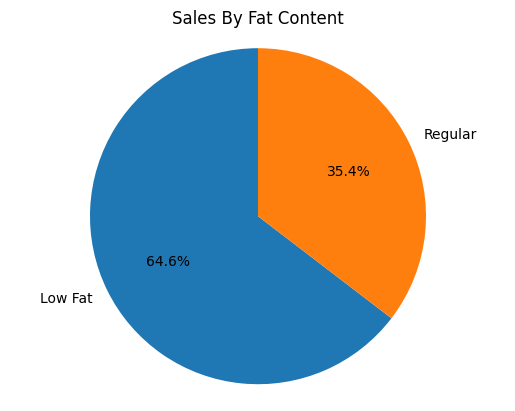

In [16]:
sales_by_fat = df.groupby("Item Fat Content")["Sales"].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index,
                        autopct="%.1f%%", 
                        startangle = 90)
plt.title("Sales By Fat Content")
plt.axis("equal")
plt.show()

##### **Total Sales By Item Type**

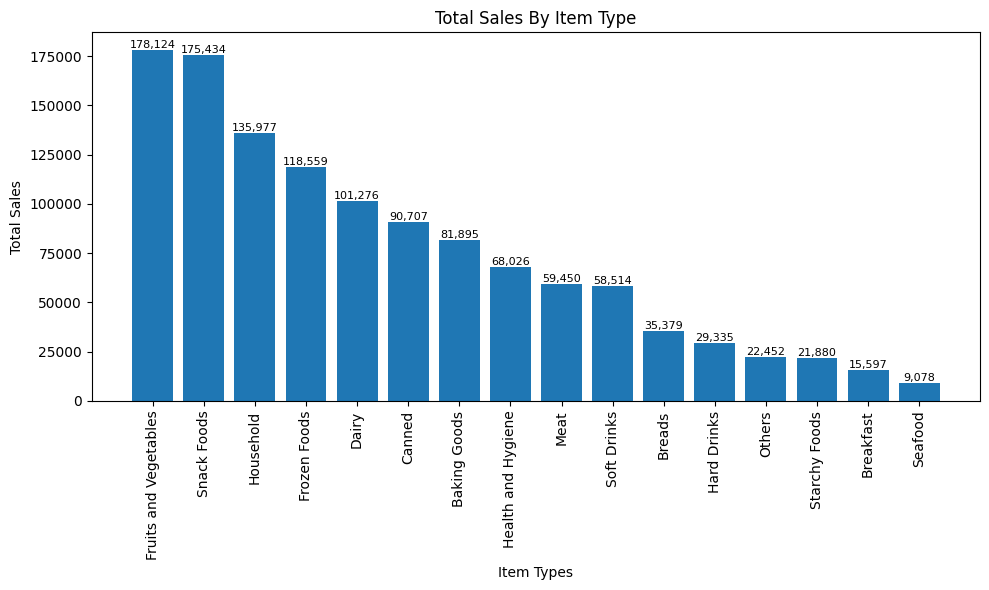

In [17]:
sales_by_item_type = df.groupby("Item Type")["Sales"].sum().sort_values(ascending = False)
# sales_by_item_type.plot(kind="bar")

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_item_type.index, sales_by_item_type.values)

plt.xticks(rotation=90)
plt.title("Total Sales By Item Type")
plt.xlabel("Item Types")
plt.ylabel("Total Sales")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.show()

##### **Fat Content By Outet for Total Sales**

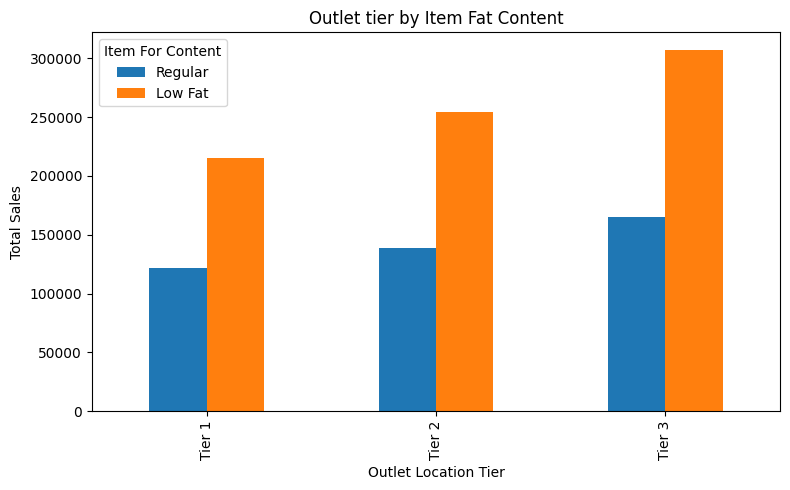

In [18]:
grouped = df.groupby(["Outlet Location Type", "Item Fat Content"])["Sales"].sum().unstack()
grouped = grouped[["Regular", "Low Fat"]]

ax = grouped.plot(kind="bar", figsize= (8,5), title= "Outlet tier by Item Fat Content")

plt.xlabel("Outlet Location Tier")
plt.ylabel("Total Sales")
plt.legend(title="Item For Content")


plt.tight_layout()
plt.show()

##### **Total Sales by Outlet Establishment Year**

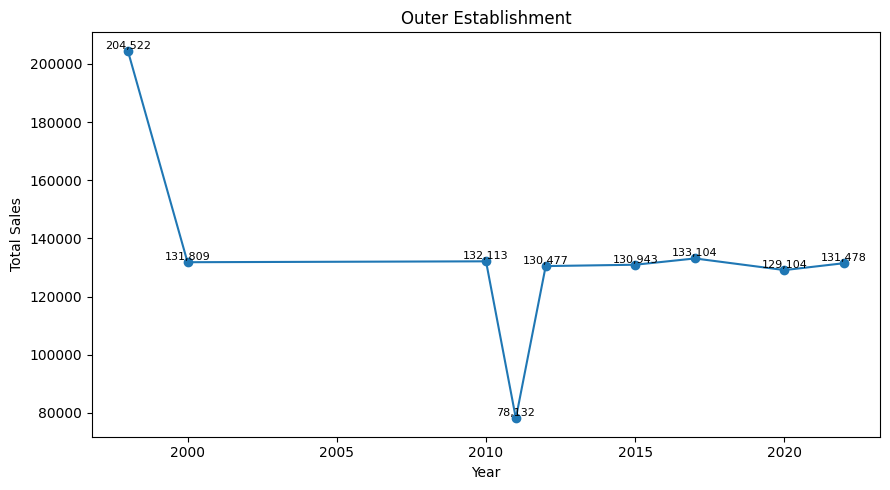

In [19]:
sale_by_year = df.groupby("Outlet Establishment Year")["Sales"].sum()
# print(sale_by_year)

plt.figure(figsize=(9,5))
plt.plot(sale_by_year.index, sale_by_year.values, marker='o', linestyle="-")

plt.title("Outer Establishment")
plt.xlabel("Year")
plt.ylabel("Total Sales")

for x, y in zip(sale_by_year.index, sale_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

##### **Total Sales by Outlet Size**

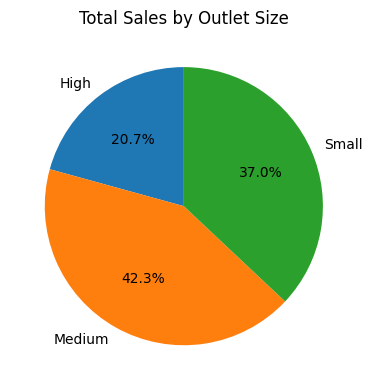

In [20]:
sales_by_size = df.groupby("Outlet Size")["Sales"].sum()
# print(sales_by_size)

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels= sales_by_size.index, autopct="%1.1f%%", startangle= 90)

plt.title("Total Sales by Outlet Size")

plt.tight_layout()
plt.show()

##### **Total Sales by Outlet Location Type**

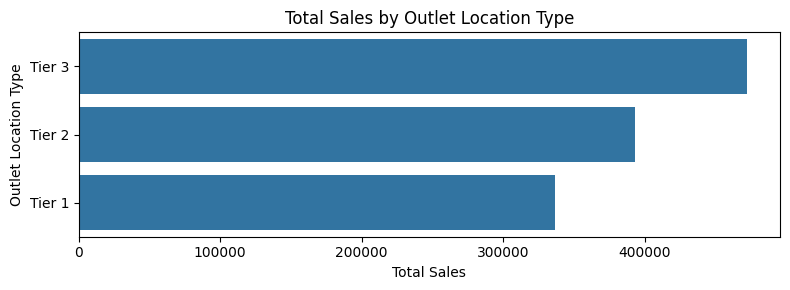

In [21]:
sales_by_location = df.groupby("Outlet Location Type")["Sales"].sum().reset_index()
sales_by_location = sales_by_location.sort_values("Sales",ascending=False)
# print(sales_by_location)

plt.figure(figsize=(8,3)) # smaller height, enough width
ax = sns.barplot(x="Sales", y="Outlet Location Type", data = sales_by_location)

plt.title("Total Sales by Outlet Location Type")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Location Type")

plt.tight_layout() # Ensure Layout fit wihtout scroll
plt.show()